# 07. 공기어(Co-occurrence) 분석 — 영어 + 한국어

## 목적
핵심 키워드가 **어떤 맥락에서 쓰이는지**를 파악한다.
같은 리뷰 안에서 함께 등장하는 단어 쌍(공기어)을 추출하고,
긍정/부정 리뷰에서 같은 단어가 다른 맥락으로 쓰이는 경우를 분석한다.

## 왜 공기어 분석이 필요한가?
- 빈도 분석(03, 04편): "boss"가 부정 리뷰에서 많다 → **왜?** 모름
- TF-IDF(05편): "boss"가 부정을 가르는 키워드다 → **어떤 맥락?** 모름
- LDA(06편): "boss"가 특정 토픽에 속한다 → **구체적으로 뭐가 문제?** 모름
- 공기어 분석: "boss" + "hard", "boss" + "unfair" → **보스전이 어렵다/불공정하다**

## 분석 순서
1. 라이브러리 & 데이터 로드
2. 공기어 추출 함수 정의
3. 영어 — 핵심 키워드 공기어 분석
4. 한국어 — 핵심 키워드 공기어 분석
5. 긍정 vs 부정 맥락 비교
6. 공기어 네트워크 시각화
7. 결과 저장

---
## 1. 라이브러리 & 데이터 로드

In [2]:
import sqlite3
import pandas as pd
import numpy as np
from collections import Counter
from itertools import combinations
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

DB_PATH = '../data/dave_diver.db'
conn = sqlite3.connect(DB_PATH)
print(' 라이브러리 로드 완료')

 라이브러리 로드 완료


In [3]:
df_en = pd.read_sql("""
    SELECT review_id, voted_up, review_month, play_segment,
           review_text, cleaned_text
    FROM cleaned_reviews_en
    WHERE cleaned_text IS NOT NULL AND cleaned_text != ''
""", conn)

df_ko = pd.read_sql("""
    SELECT review_id, voted_up, review_month, play_segment,
           review_text, cleaned_text
    FROM cleaned_reviews_ko
    WHERE cleaned_text IS NOT NULL AND cleaned_text != ''
""", conn)

print(f'영어:   {len(df_en):,}건 (긍정 {df_en["voted_up"].sum():,} / 부정 {(len(df_en)-df_en["voted_up"].sum()):,})')
print(f'한국어: {len(df_ko):,}건 (긍정 {df_ko["voted_up"].sum():,} / 부정 {(len(df_ko)-df_ko["voted_up"].sum()):,})')

영어:   44,839건 (긍정 43,190 / 부정 1,649)
한국어: 10,074건 (긍정 9,776 / 부정 298)


---
## 2. 공기어 추출 함수 정의

**공기어(co-occurrence)**: 같은 리뷰 안에서 함께 등장하는 단어 쌍.

두 가지 방식을 구현한다:
1. **특정 키워드의 공기어**: "boss"와 같은 리뷰에 나오는 단어 목록
2. **전체 공기어 쌍**: 모든 단어 쌍의 동시 등장 빈도 (네트워크 시각화용)

In [4]:
def get_cooccurrence(df, target_word, top_n=20):
    """특정 키워드와 같은 리뷰에 등장하는 공기어 추출
    
    Parameters
    ----------
    df : DataFrame (cleaned_text 컬럼 필요)
    target_word : 타겟 키워드
    top_n : 상위 몇 개 반환
    
    Returns
    -------
    Counter : {공기어: 빈도}
    """
    co_counter = Counter()
    
    for text in df['cleaned_text']:
        tokens = set(text.split())  # 리뷰 내 중복 제거
        if target_word in tokens:
            tokens.discard(target_word)  # 자기 자신 제외
            co_counter.update(tokens)
    
    return co_counter.most_common(top_n)


def get_pair_cooccurrence(df, min_count=10, top_n=50):
    """전체 단어 쌍의 공기 빈도 추출 (네트워크 시각화용)
    
    Parameters
    ----------
    df : DataFrame
    min_count : 이 빈도 미만 쌍은 제외
    top_n : 상위 몇 개 반환
    """
    pair_counter = Counter()
    
    for text in df['cleaned_text']:
        tokens = sorted(set(text.split()))  # 중복 제거 + 정렬(순서 통일)
        if len(tokens) < 2:
            continue
        # 상위 빈도 단어만 사용 (조합 폭발 방지)
        tokens = tokens[:30]
        for w1, w2 in combinations(tokens, 2):
            pair_counter[(w1, w2)] += 1
    
    return [(pair, count) for pair, count in pair_counter.most_common(top_n)
            if count >= min_count]


def compare_cooccurrence(df, target_word, top_n=15):
    """긍정/부정 리뷰에서 같은 키워드의 공기어 비교"""
    pos_df = df[df['voted_up'] == 1]
    neg_df = df[df['voted_up'] == 0]
    
    pos_co = get_cooccurrence(pos_df, target_word, top_n)
    neg_co = get_cooccurrence(neg_df, target_word, top_n)
    
    return pos_co, neg_co

1. get_cooccurrence
```python
get_cooccurrence(df_en, target_word="boring", top_n=10)
# 출력
[('repetitive', 45), ('grind', 32), ('end', 28), ('content', 21), ...]
```
- boring이 등장한 리뷰에서 같이 자주 나오는 단어 top 10
    - boring은 repetitive,grind와 주로 같이 쓰인다.

2. get_pair_coocurrence
```python
get_pair_cooccurrence(df_en, min_count=10, top_n=50)
# 출력
[(('fish', 'catch'), 1823), (('sushi', 'restaurant'), 1204), ...]
```

- 모든 단어 쌍의 공출현 빈도를 뽑아서 네트워크 시각화에 사용
    - 노드 = 단어, 엣지 = 같이 나온 횟수

3. 
```python
compare_cooccurrence(df_ko, target_word="보스전", top_n=10)
# 긍정 리뷰에서 보스전 공기어
[('재밌', 31), ('짜릿', 18), ('도전', 15), ...]

# 부정 리뷰에서 보스전 공기어
[('어렵', 42), ('짜증', 38), ('강제', 21), ...]

```
- 같은 "보스전"이라는 단어가 긍정에서는 "짜릿, 도전"과 함께 부정에서는 "어렵, 짜증, 강제"와 함께 나옴

---
## 3. 영어 — 핵심 키워드 공기어 분석

이전 분석에서 발견한 핵심 키워드의 맥락을 파악한다.

In [5]:
# ── 부정 리뷰에서 "boss"의 공기어 ──
# 03편에서 boss는 engaged(10-30h) 구간 부정 리뷰의 핵심 키워드였다

neg_en = df_en[df_en['voted_up'] == 0]

targets_en = ['boss', 'loop', 'refund', 'story', 'fight']

print('영어 부정 리뷰 — 핵심 키워드별 공기어 (Top 15)')
print('=' * 60)

for target in targets_en:
    co = get_cooccurrence(neg_en, target, top_n=15)
    n_reviews = neg_en['cleaned_text'].str.contains(f'\\b{target}\\b').sum() if target.isalpha() else \
                neg_en['cleaned_text'].apply(lambda x: target in x.split()).sum()
    print(f'\n"{target}" — 부정 리뷰 {n_reviews}건에서 등장')
    for word, count in co:
        print(f'  + {word:20s} {count:4d}건')

영어 부정 리뷰 — 핵심 키워드별 공기어 (Top 15)

"boss" — 부정 리뷰 199건에서 등장
  + fight                 121건
  + fun                   112건
  + fish                  100건
  + restaurant             81건
  + story                  80건
  + gameplay               72건
  + quest                  62건
  + new                    54건
  + find                   54건
  + try                    53건
  + upgrade                52건
  + mechanic               52건
  + loop                   49건
  + start                  49건
  + character              49건

"loop" — 부정 리뷰 205건에서 등장
  + gameplay              143건
  + fun                   106건
  + fish                   98건
  + restaurant             90건
  + story                  70건
  + mechanic               69건
  + core                   66건
  + dive                   62건
  + new                    61건
  + quest                  61건
  + day                    61건
  + enjoy                  54건
  + sushi                  54건
  + diving                 53건
  + try          

In [6]:
# ── "fun"의 긍정/부정 맥락 비교 ──

pos_co, neg_co = compare_cooccurrence(df_en, 'fun', top_n=15)

print('"fun" — 긍정 vs 부정 리뷰 공기어 비교')
print('=' * 60)

print(f'\n{"긍정에서의 공기어":30s}  {"부정에서의 공기어":30s}')
print('-' * 62)
for i in range(15):
    p = f'{pos_co[i][0]} ({pos_co[i][1]})' if i < len(pos_co) else ''
    n = f'{neg_co[i][0]} ({neg_co[i][1]})' if i < len(neg_co) else ''
    print(f'  {p:30s}  {n:30s}')

"fun" — 긍정 vs 부정 리뷰 공기어 비교

긍정에서의 공기어                       부정에서의 공기어                     
--------------------------------------------------------------
  story (2227)                    fish (177)                    
  gameplay (1741)                 restaurant (162)              
  love (1623)                     gameplay (162)                
  fish (1551)                     story (132)                   
  restaurant (1472)               mechanic (121)                
  character (1352)                quest (119)                   
  relax (1175)                    boss (112)                    
  new (1128)                      diving (109)                  
  sushi (1078)                    try (106)                     
  art (1053)                      loop (106)                    
  mechanic (1037)                 dive (106)                    
  loop (1009)                     end (106)                     
  diving (981)                    start (103)                   
 

---
## 4. 한국어 — 핵심 키워드 공기어 분석

In [7]:
neg_ko = df_ko[df_ko['voted_up'] == 0]

targets_ko = ['보스전', '노가다', '스토리', '넥슨', '환불']

print('한국어 부정 리뷰 — 핵심 키워드별 공기어 (Top 15)')
print('=' * 60)

for target in targets_ko:
    co = get_cooccurrence(neg_ko, target, top_n=15)
    n_reviews = neg_ko['cleaned_text'].apply(lambda x: target in x.split()).sum()
    print(f'\n"{target}" — 부정 리뷰 {n_reviews}건에서 등장')
    for word, count in co:
        print(f'  + {word:20s} {count:4d}건')

한국어 부정 리뷰 — 핵심 키워드별 공기어 (Top 15)

"보스전" — 부정 리뷰 20건에서 등장
  + 나오                      8건
  + 스토리                     8건
  + 생각                      6건
  + 모르                      6건
  + 물고기                     5건
  + 이후                      5건
  + 그렇                      5건
  + 만들                      5건
  + 이해                      5건
  + 마을                      5건
  + 느끼                      5건
  + 유저                      5건
  + 운영                      5건
  + 느낌                      5건
  + 미니                      4건

"노가다" — 부정 리뷰 20건에서 등장
  + 스토리                    10건
  + 만들                      8건
  + 나오                      7건
  + 재밌                      7건
  + 모르                      6건
  + 컨텐츠                     6건
  + 생각                      6건
  + 이후                      5건
  + 느끼                      5건
  + 반복                      5건
  + 자체                      5건
  + 퀘스트                     5건
  + 미니                      4건
  + 편의                      4건
  + 굉장히             

In [8]:
# ── "재밌" 긍정/부정 맥락 비교 ──
# 04편에서 "재밌"은 부정 리뷰에서도 높았다 → "재밌긴 한데..." 패턴 검증

pos_co_ko, neg_co_ko = compare_cooccurrence(df_ko, '재밌', top_n=15)

print('"재밌" — 긍정 vs 부정 리뷰 공기어 비교')
print('=' * 60)

print(f'\n{"긍정에서의 공기어":30s}  {"부정에서의 공기어":30s}')
print('-' * 62)
for i in range(15):
    p = f'{pos_co_ko[i][0]} ({pos_co_ko[i][1]})' if i < len(pos_co_ko) else ''
    n = f'{neg_co_ko[i][0]} ({neg_co_ko[i][1]})' if i < len(neg_co_ko) else ''
    print(f'  {p:30s}  {n:30s}')

"재밌" — 긍정 vs 부정 리뷰 공기어 비교

긍정에서의 공기어                       부정에서의 공기어                     
--------------------------------------------------------------
  스토리 (311)                       만들 (14)                       
  컨텐츠 (278)                       재미 (10)                       
  만들 (256)                        모르 (9)                        
  나오 (247)                        생각 (9)                        
  물고기 (241)                       나오 (9)                        
  생각 (214)                        미니 (8)                        
  모르 (197)                        스토리 (7)                       
  즐기 (195)                        노가다 (7)                       
  넥슨 (174)                        마을 (7)                        
  정식 (172)                        초반 (6)                        
  힐링 (164)                        처음 (6)                        
  도트 (158)                        퍼즐 (6)                        
  재미 (156)                        짜증 (5)                        
  

In [9]:
# ── "넥슨" 긍정/부정 맥락 비교 ──
# 04편에서 넥슨이 전체 3위 → 퍼블리셔 평판이 리뷰에 미치는 영향 검증

pos_co_nx, neg_co_nx = compare_cooccurrence(df_ko, '넥슨', top_n=15)

print('"넥슨" — 긍정 vs 부정 리뷰 공기어 비교')
print('=' * 60)

print(f'\n{"긍정에서의 공기어":30s}  {"부정에서의 공기어":30s}')
print('-' * 62)
for i in range(15):
    p = f'{pos_co_nx[i][0]} ({pos_co_nx[i][1]})' if i < len(pos_co_nx) else ''
    n = f'{neg_co_nx[i][0]} ({neg_co_nx[i][1]})' if i < len(neg_co_nx) else ''
    print(f'  {p:30s}  {n:30s}')

"넥슨" — 긍정 vs 부정 리뷰 공기어 비교

긍정에서의 공기어                       부정에서의 공기어                     
--------------------------------------------------------------
  만들 (305)                        만들 (9)                        
  재밌 (174)                        나오 (8)                        
  나오 (142)                        모르 (6)                        
  생각 (120)                        스토리 (6)                       
  스토리 (104)                       생각 (5)                        
  컨텐츠 (103)                       느낌 (5)                        
  도트 (80)                         평가 (5)                        
  갓겜 (78)                         재밌 (5)                        
  기대 (77)                         자체 (5)                        
  출시 (76)                         미니 (4)                        
  물고기 (69)                        절대 (4)                        
  재미 (69)                         엔딩 (4)                        
  보이 (68)                         가게 (4)                        
  

---
## 5. 긍정 vs 부정 — 같은 단어, 다른 맥락

긍정/부정 양쪽에서 공통으로 등장하지만 **공기어가 다른** 키워드를 찾는다.
이게 이 분석의 핵심이다.

In [10]:
def context_difference(df, target_word, top_n=15):
    """긍정/부정에서 공기어 차이 분석
    
    긍정에서만 나오는 공기어, 부정에서만 나오는 공기어,
    양쪽 모두 나오는 공기어를 분리한다.
    """
    pos_co = dict(get_cooccurrence(df[df['voted_up'] == 1], target_word, top_n * 2))
    neg_co = dict(get_cooccurrence(df[df['voted_up'] == 0], target_word, top_n * 2))
    
    pos_only = {w: c for w, c in pos_co.items() if w not in neg_co}
    neg_only = {w: c for w, c in neg_co.items() if w not in pos_co}
    shared   = {w: (pos_co.get(w, 0), neg_co.get(w, 0)) for w in set(pos_co) & set(neg_co)}
    
    return pos_only, neg_only, shared


# ── 영어 "story" ──
print('"story" — 긍정/부정 맥락 차이')
print('=' * 60)
pos_only, neg_only, shared = context_difference(df_en, 'story')

print(f'\n긍정에서만 나오는 공기어 (Top 10):')
for w, c in sorted(pos_only.items(), key=lambda x: -x[1])[:10]:
    print(f'  + {w:20s} {c:4d}건')

print(f'\n부정에서만 나오는 공기어 (Top 10):')
for w, c in sorted(neg_only.items(), key=lambda x: -x[1])[:10]:
    print(f'  + {w:20s} {c:4d}건')

print(f'\n양쪽 모두 등장 — 비율 차이가 큰 것 (Top 10):')
# 부정 비율이 높은 순으로 정렬
for w, (pc, nc) in sorted(shared.items(), key=lambda x: -(x[1][1]/(x[1][0]+x[1][1]+1)))[:10]:
    total = pc + nc
    print(f'  {w:20s}  긍정 {pc:4d} / 부정 {nc:4d}  (부정비율 {nc/total*100:.0f}%)')

"story" — 긍정/부정 맥락 차이

긍정에서만 나오는 공기어 (Top 10):
  + love                 1221건
  + art                   864건
  + sushi                 794건
  + content               730건
  + amazing               656건
  + relax                 642건
  + interesting           636건
  + run                   628건
  + style                 628건
  + mini                  610건

부정에서만 나오는 공기어 (Top 10):
  + quest                  80건
  + try                    74건
  + progress               73건
  + start                  72건
  + end                    67건
  + minigame               66건
  + need                   65건
  + people                 65건
  + upgrade                62건
  + point                  62건

양쪽 모두 등장 — 비율 차이가 큰 것 (Top 10):
  boss                  긍정  580 / 부정   80  (부정비율 12%)
  find                  긍정  561 / 부정   67  (부정비율 11%)
  day                   긍정  625 / 부정   70  (부정비율 10%)
  restaurant            긍정 1124 / 부정  123  (부정비율 10%)
  fish                  긍정 1191 / 부정  130  (부정비율 10%)
  div

In [11]:
# ── 한국어 "스토리" ──
print('"스토리" — 긍정/부정 맥락 차이')
print('=' * 60)
pos_only, neg_only, shared = context_difference(df_ko, '스토리')

print(f'\n긍정에서만 나오는 공기어 (Top 10):')
for w, c in sorted(pos_only.items(), key=lambda x: -x[1])[:10]:
    print(f'  + {w:20s} {c:4d}건')

print(f'\n부정에서만 나오는 공기어 (Top 10):')
for w, c in sorted(neg_only.items(), key=lambda x: -x[1])[:10]:
    print(f'  + {w:20s} {c:4d}건')

print(f'\n양쪽 모두 등장 — 부정 비율 높은 순 (Top 10):')
for w, (pc, nc) in sorted(shared.items(), key=lambda x: -(x[1][1]/(x[1][0]+x[1][1]+1)))[:10]:
    total = pc + nc
    print(f'  {w:20s}  긍정 {pc:4d} / 부정 {nc:4d}  (부정비율 {nc/total*100:.0f}%)')

"스토리" — 긍정/부정 맥락 차이

긍정에서만 나오는 공기어 (Top 10):
  + 재밌                    311건
  + 즐기                    152건
  + 도트                    127건
  + 그래픽                   121건
  + 아쉽                    119건
  + 다양                    116건
  + 힐링                    110건
  + 많이                    109건
  + 넥슨                    104건
  + 메인                    103건

부정에서만 나오는 공기어 (Top 10):
  + 미니                     14건
  + 노가다                    10건
  + 이상                     10건
  + 마을                     10건
  + 경영                      8건
  + 좋아하                     8건
  + 속도                      8건
  + 보스전                     8건
  + 처음                      8건
  + 문제                      8건

양쪽 모두 등장 — 부정 비율 높은 순 (Top 10):
  모르                    긍정   95 / 부정   16  (부정비율 14%)
  느낌                    긍정  131 / 부정   16  (부정비율 11%)
  퀘스트                   긍정   93 / 부정    9  (부정비율 9%)
  요소                    긍정  119 / 부정   11  (부정비율 8%)
  운영                    긍정  126 / 부정   11  (부정비율 8%)
  나오      

---
## 6. 공기어 네트워크 시각화

부정 리뷰에서 자주 함께 등장하는 단어 쌍을 네트워크 그래프로 시각화한다.
노드 = 단어, 엣지 = 공기 빈도.

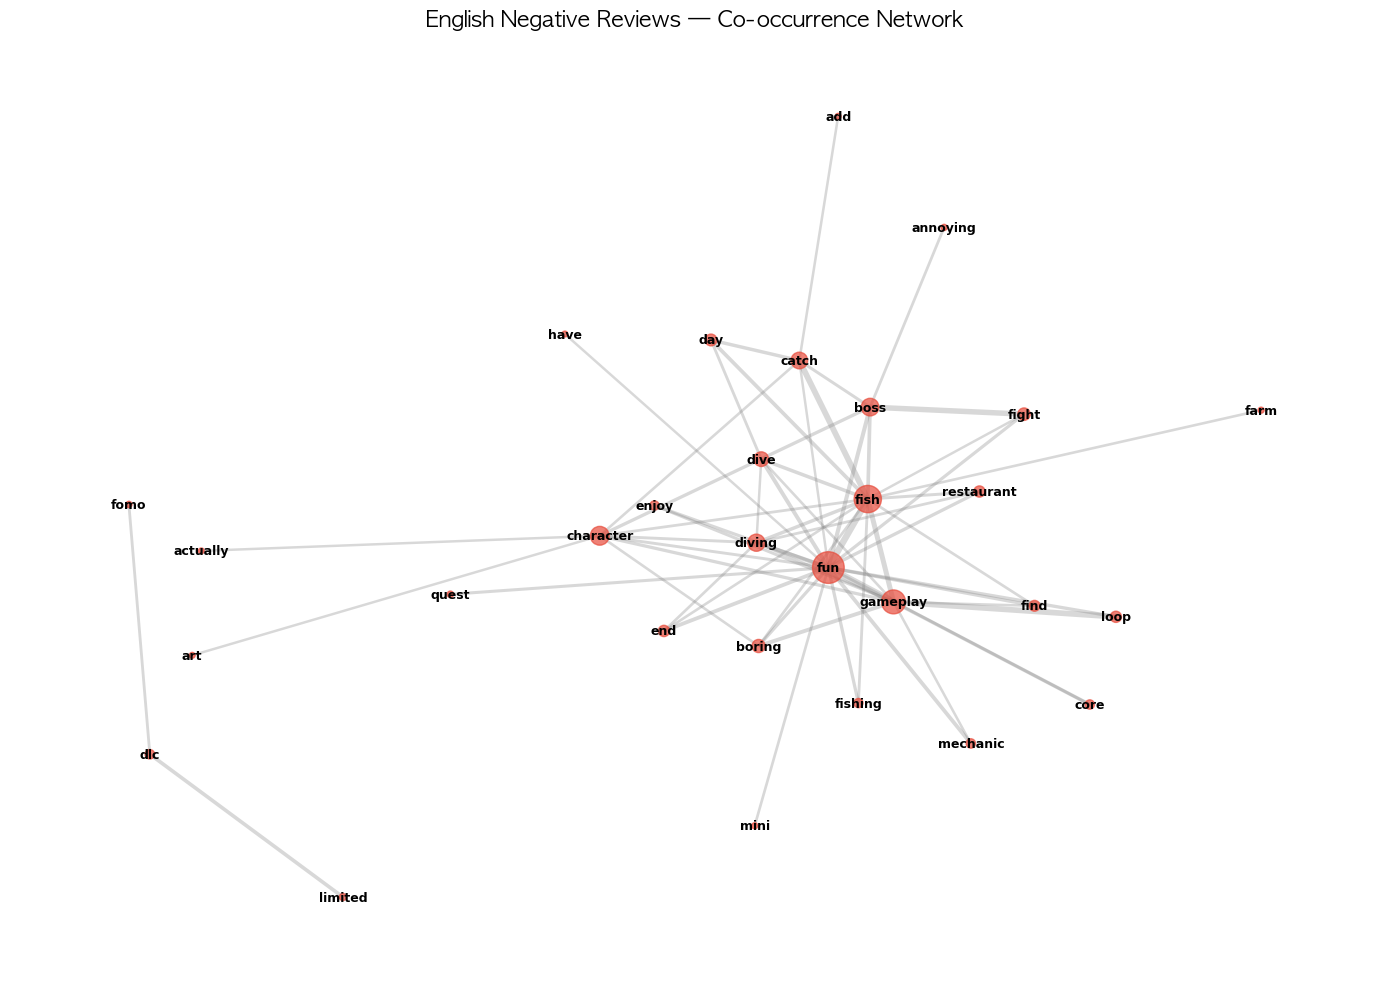

저장: reports/figures/cooccurrence_network_en.png
   노드 30개, 엣지 60개


In [12]:
# ── 영어 부정 리뷰 공기어 네트워크 ──
pairs_en = get_pair_cooccurrence(neg_en, min_count=20, top_n=60)

G = nx.Graph()
for (w1, w2), count in pairs_en:
    G.add_edge(w1, w2, weight=count)

fig, ax = plt.subplots(figsize=(14, 10))

pos = nx.spring_layout(G, k=2, seed=42)

# 노드 크기 = 연결된 엣지 가중치 합
node_sizes = [sum(G[n][nbr]['weight'] for nbr in G[n]) * 0.5 for n in G.nodes()]
# 엣지 두께 = 공기 빈도
edge_weights = [G[u][v]['weight'] * 0.05 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#E74C3C', alpha=0.7, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.3, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)

ax.set_title('English Negative Reviews — Co-occurrence Network', fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../reports/figures/cooccurrence_network_en.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: reports/figures/cooccurrence_network_en.png')
print(f'   노드 {G.number_of_nodes()}개, 엣지 {G.number_of_edges()}개')

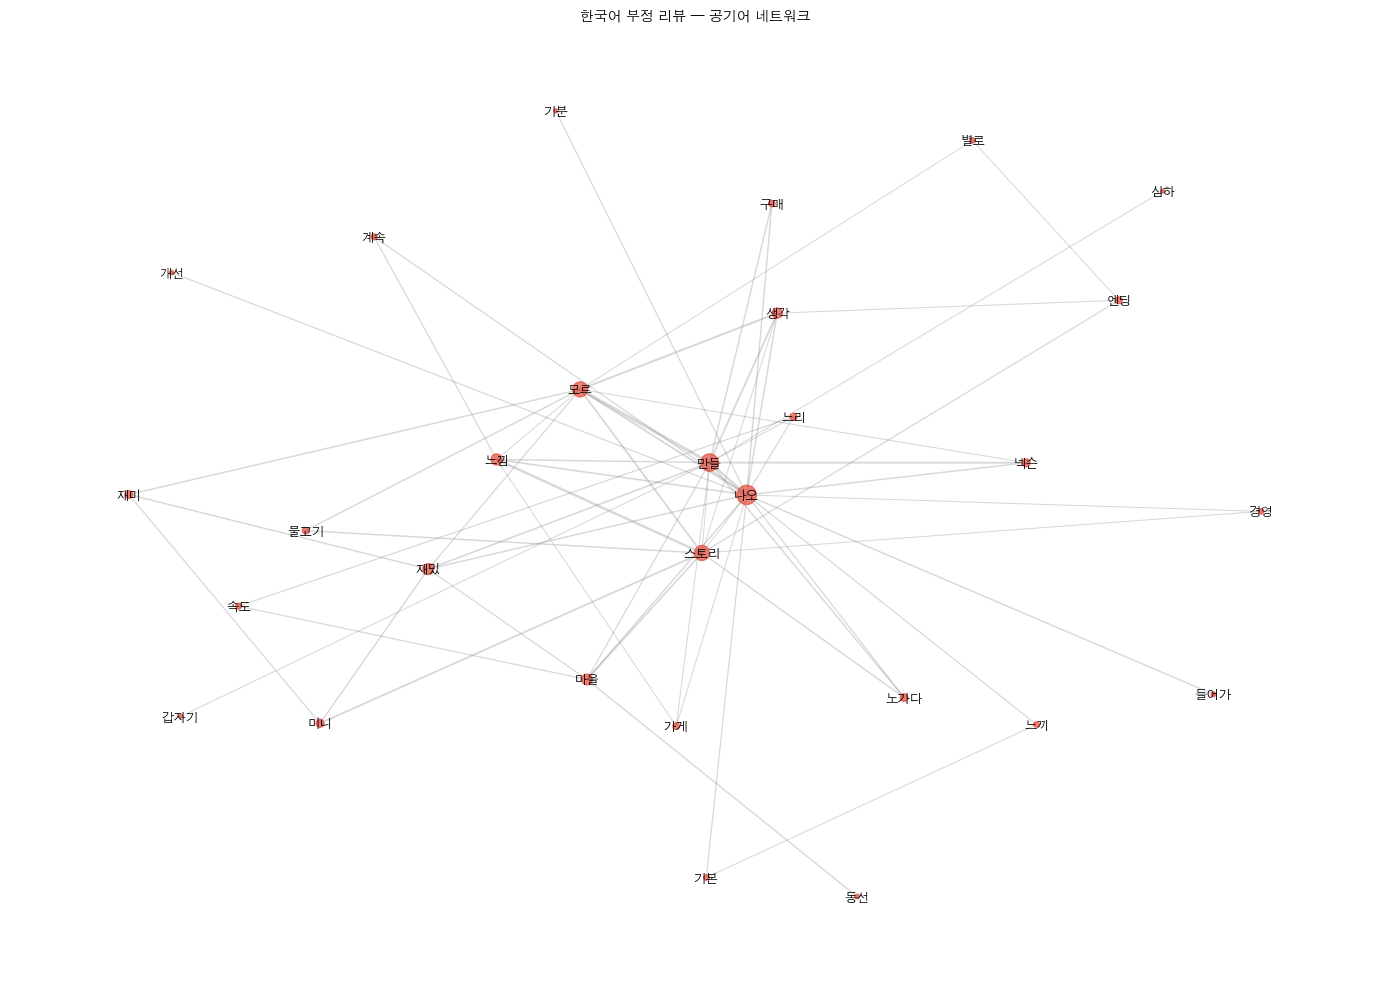

저장: reports/figures/cooccurrence_network_ko.png
   노드 29개, 엣지 60개


In [13]:
#폰드재설정
import matplotlib.font_manager as fm
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

# ── 한국어 부정 리뷰 공기어 네트워크 ──
pairs_ko = get_pair_cooccurrence(neg_ko, min_count=5, top_n=60)

G_ko = nx.Graph()
for (w1, w2), count in pairs_ko:
    G_ko.add_edge(w1, w2, weight=count)

fig, ax = plt.subplots(figsize=(14, 10))

pos = nx.spring_layout(G_ko, k=2, seed=42)

node_sizes = [sum(G_ko[n][nbr]['weight'] for nbr in G_ko[n]) * 1.5 for n in G_ko.nodes()]
edge_weights = [G_ko[u][v]['weight'] * 0.15 for u, v in G_ko.edges()]

nx.draw_networkx_nodes(G_ko, pos, node_size=node_sizes, node_color='#E74C3C', alpha=0.7, ax=ax)
nx.draw_networkx_edges(G_ko, pos, width=edge_weights, alpha=0.3, edge_color='gray', ax=ax)
nx.draw_networkx_labels(
    G_ko, pos,
    font_size=9,
    font_weight='bold',
    font_family=font_name,  # ← 이게 핵심
    ax=ax
)

# title도 fontproperties로
ax.set_title('한국어 부정 리뷰 — 공기어 네트워크',
             fontsize=16, fontweight='bold',
             fontproperties=font_prop)

ax.axis('off')
plt.tight_layout()
plt.savefig('../reports/figures/cooccurrence_network_ko.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: reports/figures/cooccurrence_network_ko.png')
print(f'   노드 {G_ko.number_of_nodes()}개, 엣지 {G_ko.number_of_edges()}개')

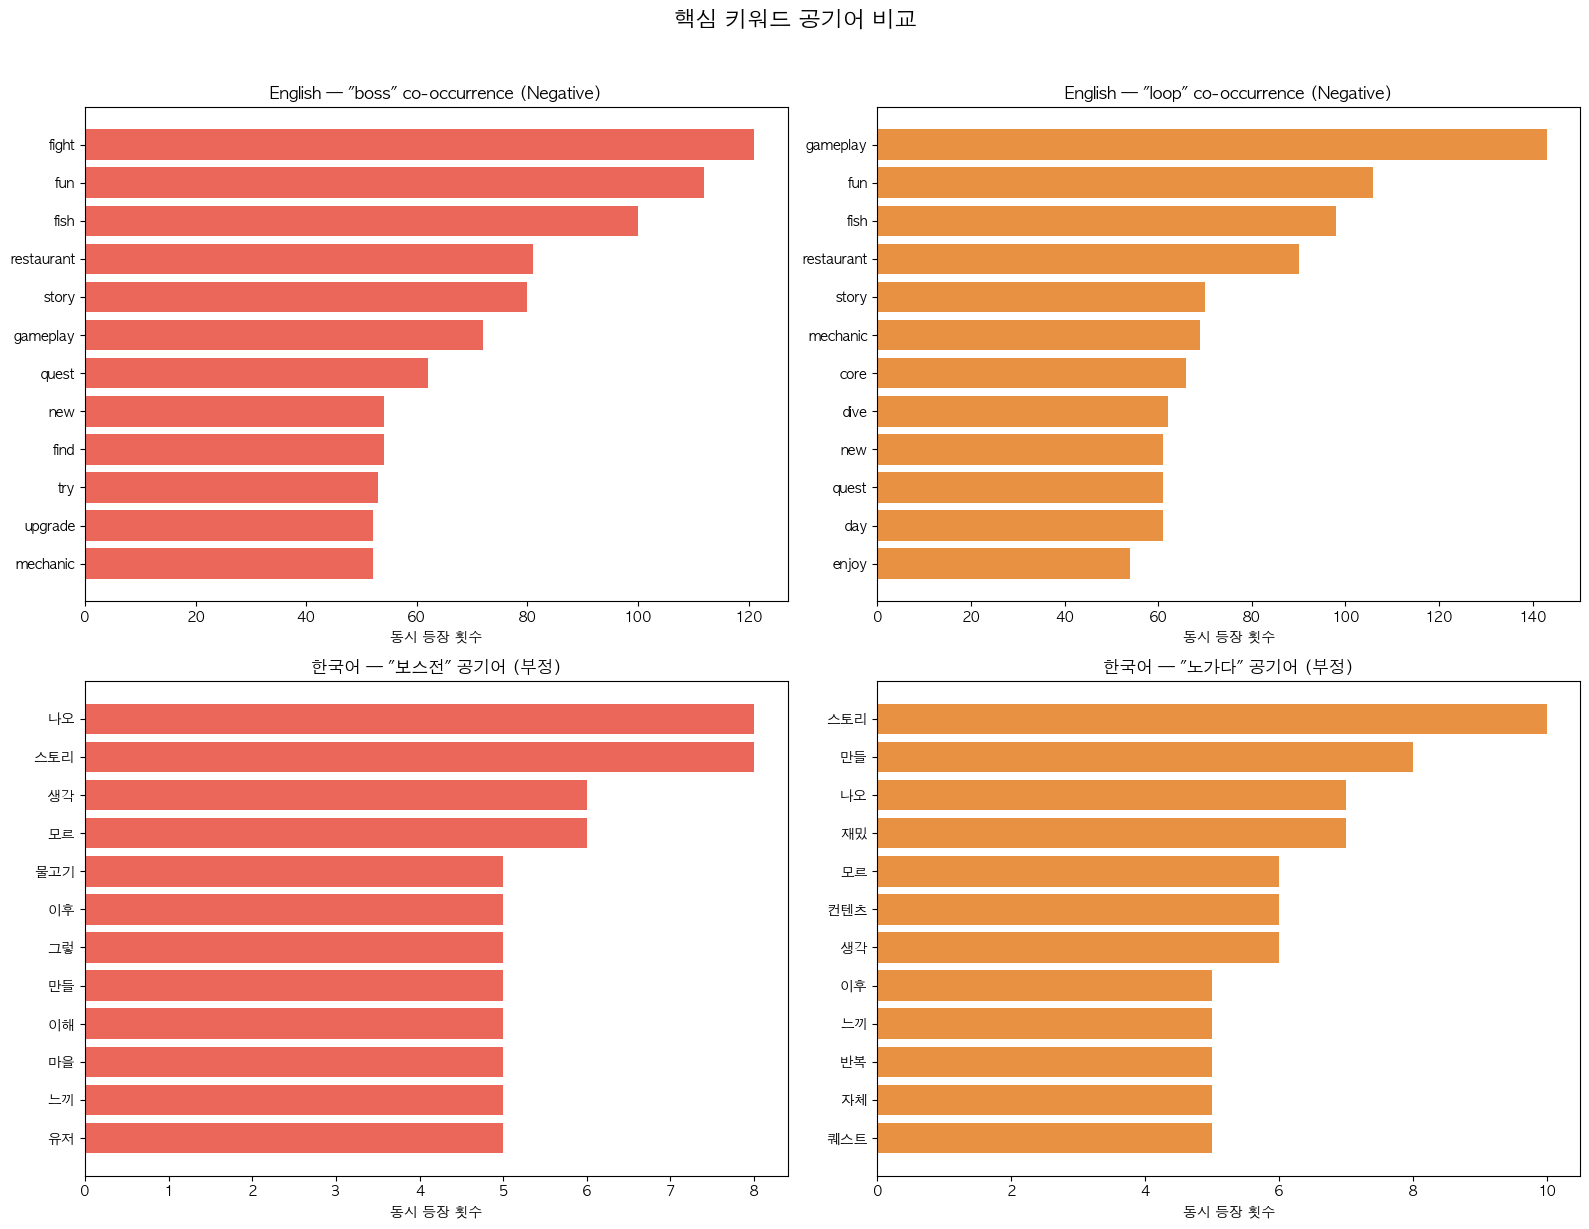

 저장: reports/figures/cooccurrence_bars.png


In [14]:
# ── 특정 키워드 공기어 바 차트 (networkx 불필요) ──

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

charts = [
    (axes[0, 0], neg_en, 'boss', 'English — "boss" co-occurrence (Negative)', '#E74C3C'),
    (axes[0, 1], neg_en, 'loop', 'English — "loop" co-occurrence (Negative)', '#E67E22'),
    (axes[1, 0], neg_ko, '보스전', '한국어 — "보스전" 공기어 (부정)', '#E74C3C'),
    (axes[1, 1], neg_ko, '노가다', '한국어 — "노가다" 공기어 (부정)', '#E67E22'),
]

for ax, df_neg, target, title, color in charts:
    co = get_cooccurrence(df_neg, target, top_n=12)
    if co:
        words = [w for w, c in co]
        counts = [c for w, c in co]
        ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('동시 등장 횟수')

plt.suptitle('핵심 키워드 공기어 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/cooccurrence_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: reports/figures/cooccurrence_bars.png')

---
## 7. 원문 검증

공기어 분석 결과가 실제 리뷰에서 어떤 맥락인지 확인한다.

In [15]:
# ── "boss" + 상위 공기어 조합의 원문 확인 ──
print('"boss" + 공기어 조합 — 원문 샘플')
print('=' * 70)

boss_co = get_cooccurrence(neg_en, 'boss', top_n=5)

for co_word, _ in boss_co[:2]:
    matched = neg_en[
        neg_en['cleaned_text'].apply(lambda x: 'boss' in x.split() and co_word in x.split())
    ]
    print(f'\n"boss" + "{co_word}" ({len(matched)}건):')
    for _, row in matched.head(7).iterrows():
        text = row['review_text'].replace('\n', ' ')[:200]
        print(f'  • {text}')

"boss" + 공기어 조합 — 원문 샘플

"boss" + "fight" (121건):
  • Good game but the bosses are near impossible to fight unless you nail the exact strategy.
 The core gameplay loop, fishing, exploring, and serving sushi is fun but nish it. This game is a mile wide, but an inch deep. 
  • At first it's nice, I just want to play fishing game. then have to fight some bosses. It's still manageable, then I have to fight human and with precise timing. what the hell is this fight. I retried 
  • Ok, so I thought this game was amazing but I changed my mind in the meantime...it's pretty awful and ♥♥♥♥♥♥♥ patriarchal. You are pushed into random boss fights randomly and not giving any help or cha
  • The boss fights are stupid.  The rest is okay.
  • Not a full thumbs down, I honestly really love this game except for these f*cking boss fights. Primarily the non-optional ones that give you no warning whatsoever and one of them apparently gives fals
  • Could have been great, but the boss fights, combined with 

In [16]:
# ── "loop" + core 조합의 원문 확인 ──
matched = neg_en[
    neg_en['cleaned_text'].apply(lambda x: 'loop' in x.split() and 'core' in x.split())
]
print(f'"loop" + "core" ({len(matched)}건):')
for _, row in matched.head(6).iterrows():
    text = row['review_text'].replace('\n', ' ')[:400]
    print(f'  • {text}')

"loop" + "core" (66건):
  • The Positives: The start of the game is really solid and has a really tight, satisfying gameplay loop where you dive down, collect fish, sell your fish in your restaurant, and then use those funds to upgrade your gear so you can dive down a little bit further and collect new and better fish. Initially, each dive is about 10 minutes long, but as you upgrade your gear the length of these dives incre
 This is made worse by the fact the story itsend serving sushi is fun but the game's story insists on continual boring puzzles or fetch quests that only serve to deviate from what makes the game enjoyable in the first place. 
  • Core gameplay loop (fishing vs restaurant management) is interesting, but in practice the mechanics just did not hook me in as well as I had hoped. Fishing/hunting is repetitive and honestly not that interesting or fun. The restaurant management lacks depth (which is fine), the minigames were tedious as well. Shame as I really wanted to lik

In [24]:
# ── refund + force 조합의 원문 확인 ──
matched = neg_en[
    neg_en['cleaned_text'].apply(lambda x: 'refund' in x.split() and 'force' in x.split())
]
print(f'"refund" + "force" ({len(matched)}건):')
for _, row in matched.head(4).iterrows():
    text = row['review_text'].replace('\n', ' ')[:1000]
    print(f'  • {text}')

"refund" + "force" (9건):
  • Don't believe the Overwhelmingly Positive score.  Wildly overrated.  Yet another rouge-lite where you are forced to progress an inch at a time to pad the game.  The actual gameplay harpooning fish controls really poorly and the minimalist graphics make it extremely difficult to identify harmless objects and threats.  You also have to do all of these random things like serve food.  The writing is the typical "lol random self-aware" indie game tropes and nonsense.  The biggest problem. and I instantly refund any game with this glaring flaw... the game has non-stop screen tearing and there is no v-sync.  See ya later!!!
  • Never seen a game softlock you and punish you by default by following the story. Bancho asks me to get shark for Yoshie (I also hate the fact that this game has forced hard combat but whatever), so I try to go out but "You can't fish at night." Okay so I have to lose money to complete the story, great. I also cannot continue with the story 

In [18]:
# ── "넥슨" + 공기어 조합의 원문 확인 ──
print('"넥슨" + 공기어 조합 — 원문 샘플')
print('=' * 70)

nexon_co = get_cooccurrence(df_ko, '넥슨', top_n=5)  # 전체 리뷰 대상 (긍정 포함)

for co_word, _ in nexon_co[:3]:
    matched = df_ko[
        df_ko['cleaned_text'].apply(lambda x: '넥슨' in x.split() and co_word in x.split())
    ]
    print(f'\n"넥슨" + "{co_word}" ({len(matched)}건):')
    for _, row in matched.head(3).iterrows():
        text = row['review_text'].replace('\n', ' ')[:200]
        print(f'  • {text}')

"넥슨" + 공기어 조합 — 원문 샘플

"넥슨" + "만들" (314건):
  • 명작이란 얘기는 들어서 시간 날 때 해봐야지 하고 마음 먹었는데, 마침 세일을 해서 구매했다.  죽으면 다 날라가는 점이 조금 짜증나긴 했지만 잔잔하고 B급 유머가 너무 재밌었고..  넥슨에서 이런 게임 만든다는거도 놀라웠다.  설날 연휴에 정말 재밌게 잘 즐겼다.  정가 주가 샀어도 돈 1도 안아까웠을듯 싶고 제작진에게 찬사를 보낸다.
  • 너무 좋았어요 진짜 바다 속에서 잘 놀다갑니다. 넥슨에서도 이런 게임을 만들 수 있구나 놀랐네요. 너무 선입견이었나 봅니다. 넥슨 화이팅 한국 게임 화이팅!
 딱 2시간 긴가민엇는지 모르겠을정도로 불쾌한 아트만 가득함 딱히 퀄이 높다는 느낌도 못받았음분나쁨)로인게임

"넥슨" + "재밌" (179건):
  • 명작이란 얘기는 들어서 시간 날 때 해봐야지 하고 마음 먹었는데, 마침 세일을 해서 구매했다.  죽으면 다 날라가는 점이 조금 짜증나긴 했지만 잔잔하고 B급 유머가 너무 재밌었고..  넥슨에서 이런 게임 만든다는거도 놀라웠다.  설날 연휴에 정말 재밌게 잘 즐겼다.  정가 주가 샀어도 돈 1도 안아까웠을듯 싶고 제작진에게 찬사를 보낸다.
  • 넥슨게임 10년넘게 하면서 욕안나오면서 재밌는게임은 처음임
  • 기본적인 타이쿤의 짜임새를 갖춰서 평균적인 재미는 보장하지만 딱 그 정도 명작게임이 가져야 할 그 어떤 깊은 철학이나 아이덴티티같은 그 이상은 없었음  -스토리, 등장인물 설정등이 다소 올드함 -전체적으로 아재감성+십덕+왜색이 짙음 -어인섬 스토리가 진지하게 너무 재미없음 -uiux가 미흡함 너무 크거나 작거나 인터페이스가 일관성이 없어 짜증남 -자유도를 

"넥슨" + "나오" (150건):
 딱 2시간 긴가민엇는지 모르겠을정도로 불쾌한 아트만 가득함 딱히 퀄이 높다는 느낌도 못받았음분나쁨)로인게임
  • 넥슨게임 10년넘게 하면서 욕안나오면서 재밌는게임은 처음임
  • 넥슨에서 만들었다고는 믿기지않는 수작.. 바다탐험도 너

In [26]:
# ── 노가다+스토리 조합의 원문 확인 ──
matched = neg_ko[
    neg_ko['cleaned_text'].apply(lambda x: '노가다' in x.split() and '스토리' in x.split())
]
print(f'"노가다" + "스토리" ({len(matched)}건):')
for _, row in matched.head(6).iterrows():
    text = row['review_text'].replace('\n', ' ')[:1000]
    print(f'  • {text}')

"노가다" + "스토리" (10건):
  • 그래픽과 사운드는 정말 잘만들었음. 극초반부에 탐험할때의 재미는 정말 최고.  근데 그 이후로는  1. 스토리 내 사건들이 납득이 잘 안된다. 묶여있는 거대 괴물한테 다가가니까 갑자기 스스로 사슬을 풀고 벽을 다 부수면서 따라오는데, 그런 힘이 있었으면 왜 갇혀 있던 건지 모르겠고, 마지막에 따돌릴 때는 돌 무더기를 쓰러트려서 막는데 벽도  가볍게 부수는 애를 돌 무더기 정도로 제압한다는 것도 납득이 잘 안됨. 씨블루 비밀기지 침투할 때도 출입구 닫혔는데 어떻게 탈출한 건지 등등 이해가 안되는 사건들이 굉장히 많음. 2. 이동속도가 느린 캐릭터로 일일히 다 돌아다녀야하는 것이 상당히 불편하다 &  기타 편의성도 부족하다 3. 머리를 전혀 안써도 되는 단순 왔다갔다 노가다 퍼즐 & 직관적으로 알기 힘든 보스패턴이나 퍼즐들(그나마 무한 재도전 할 수 있게 만들어 놓음) 때문에 하는 내내 스트레스가 조금씩 누적되는것같음. 그리고 서브로 제공되는 컨텐츠들(갸오, 미니게임, 도박 등등)이 있는데, 본 게임에 몰입하던 중에 갑자기 오타쿠 응원 리듬게임을 강제로 하게 하는 것도 , 상어 이빨 도박 컨텐츠를 할 때 턴 진행이 주우우운내 느린 것도 조금 조금씩 스트레스를 유발한다. 그냥 서브 컨텐츠들을 좀 줄이고 메인 컨텐츠와 스토리를 더 개선해줬으면 좋겠다.
  • 기본적인 게임은 재밌으나... (더보기)   과하다 싶을 정도로 미니게임+서브이벤트가 많음 등장인물이 전부 주인공(플레이어)한테 일시켜서 짜증남 손이없나 발이없나 스토리 진행만 후딱 하고 엔딩보고 싶은데 그외 사소한게 너무 많아서 피곤해짐 한마디로 노가다성이 심함 새로운 미니게임 나올때면 한숨나옴 어인족 스토리 밀때 심부름 하느라 다이빙 한번에 30분 넘게 걸릴때도 있으나 중간 세이브가 안돼서 쉬고싶어도 억지로 노가다 해야함  노가다 게임 정말 좋아하는 사람인데 단순히 몇몇 가짓수의 행위만 반복하는 게 아니라 너무 할일이 다양해서 정신없음. 오히려 불호 요소가 됨  그

In [28]:
# ── 넥슨+절대 조합의 원문 확인 ──
matched = neg_ko[
    neg_ko['cleaned_text'].apply(lambda x: '넥슨' in x.split() and '기분' in x.split())
]
print(f'"넥슨" + "기분" ({len(matched)}건):')
for _, row in matched.head(6).iterrows():
    text = row['review_text'].replace('\n', ' ')[:1000]
    print(f'  • {text}')

"넥슨" + "기분" (4건):
 그래도 샀으니까 엔딩은 보려고 꾸역꾸역했습니다 근데 2시간쯤부터 존나 재미없었어요 저는겜은아닌듯쁨)로인게임
  • 게임은 재밌는데 중간에 씹덕겜은 왜 시키는거냐 스킵도 안돼 심지어  넥슨서 하던 망한 씹덕겜이라는데 장사 망했으면 곱게 접고 새 장사 차리지  뒤진 씹덕겜 xx 주무르면서 타겜유저들한테 츄라이 츄라이 시키는건  대체 누구 머가리서 나온 전략이냐  아예 씹덕겜 새로 하나 만들어서 거기다 이런거 넣었으면 이해라도 함.  주광고 대상이 씹덕이니까  근데 유명한 게임이라서 산 비씹덕들이  퇴근하고 집 와서 겜켰는데 씹덕 콘서트 가서 경광등 흔들어 재끼라고 하면  누가 기분좋아함?
  • 장점이나 기타 특성들은 다른 분들 리뷰가 많고 대부분 동의할만한 것들이라 언급하지 않겠음 그냥 엔딩보고 이후 컨텐츠를 다 하지는 못했지만 어느정도 생각을 해보고 작성해 봄 사람마다 생각이 다를 수 있는 부분들이라 단점보다 의문점이라고 말하겠음  근본적인 의문점 : 왜 데이브는 다이빙을 하는 것인가?? 당연히 '힐링게임'에 그런 의문을 왜 가지냐?라고 말할 수 있음 하지만 그럼에도 플레이어가 왜 이 데이브라는 인물을 컨트롤 해서 반쵸의 스시가게를 키워나가야 하는지 설명이 하나도 되지 않음  그래픽 의문점 : 스타일이 기묘하게 섞여있는데 수상할 정도로 부자연스러운 3D가 종종 나오는 부분들이 의도한 것인지?아니면 그냥 유니크 한 친구들은 픽셀아트로 이쁘게 하고 별거 아닌 것들은 3D로 제작해서 작업량을 줄이려고 한 것인지?라는 생각이 듬  사운드 의문점 : 사운드 디자이너가 없나?싶을 정도임 각종 액션 사운드들은 스톡 사운드 그대로 사용한 것 같은 수준이고. 부자연스러운 사운드가 너무 많음, 배경음악은 더 심각한데 가게 브금도 너무 힙합느낌이고 그냥 배경음악이 안어울리는 경우가 너무 많음 특히 새끼 매니티를 구하는 곳 입구를 열기 위해 돌을 떨어뜨리는 곳인데 왜 최종장으로 가는 듯한 느낌의 브금을 사용하는 것일까 싶었음  인종차별적인 부분과 

---
## 8. 결과 저장

In [19]:
# ── 주요 키워드 공기어 저장 ──
co_rows = []

# 영어 부정
for target in targets_en:
    for word, count in get_cooccurrence(neg_en, target, top_n=15):
        co_rows.append({
            'language': 'english', 'sentiment': 'negative',
            'target_word': target, 'co_word': word, 'count': count
        })

# 한국어 부정
for target in targets_ko:
    for word, count in get_cooccurrence(neg_ko, target, top_n=15):
        co_rows.append({
            'language': 'korean', 'sentiment': 'negative',
            'target_word': target, 'co_word': word, 'count': count
        })

co_df = pd.DataFrame(co_rows)
co_df.to_sql('cooccurrence_results', conn, if_exists='replace', index=False)

print(f' DB 저장 완료: cooccurrence_results {len(co_df)}건')

 DB 저장 완료: cooccurrence_results 150건


---
## 9. DB 연결 종료

In [20]:
conn.close()
print('DB 연결 종료')

DB 연결 종료
